In [41]:
import numpy as np
import matplotlib.pyplot as plt

def manifold_f(x, omega=1.0):
    """
    Target function representing the model manifold.
    x: array of shape (n_samples, 2)
    """
    return np.sin(omega * x[:, 0]) + np.sin(omega * x[:, 1])

def get_gradient(x, omega=1.0):
    """
    Analytical gradient of the manifold.
    Used as the 'local truth' for our constraints.
    """
    grad_x1 = omega * np.cos(omega * x[:, 0])
    grad_x2 = omega * np.cos(omega * x[:, 1])
    return np.stack([grad_x1, grad_x2], axis=1)

In [42]:
def interrogate_neighborhood(x_star, epsilon=0.1, n_samples=50, omega=1.0):
    """
    Samples gradients in the L2 ball around x_star.
    These gradients form the 'walls' of our Admissibility Cone.
    """
    # Generate random points in the neighborhood
    offsets = np.random.normal(0, 1, (n_samples, 2))
    norms = np.linalg.norm(offsets, axis=1, keepdims=True)
    offsets = (offsets / norms) * np.random.uniform(0, epsilon, (n_samples, 1))
    
    x_neighborhood = x_star + offsets
    gradients = get_gradient(x_neighborhood, omega)
    
    return gradients

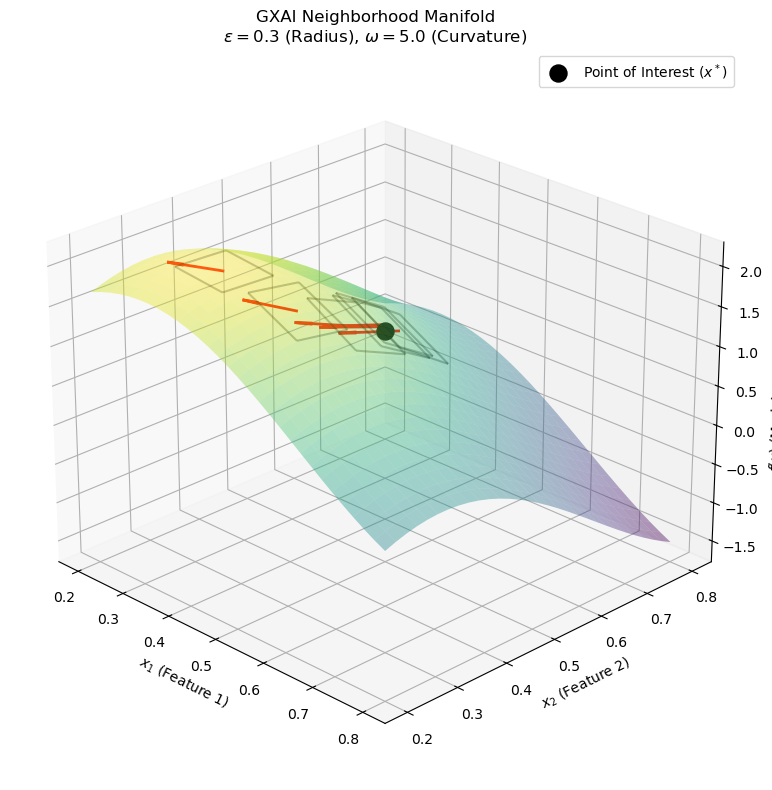

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. THEORETICAL MANIFOLD FUNCTIONS ---
def manifold_f(x, omega=1.0):
    """Target function: f(x) = sin(w*x1) + sin(w*x2)"""
    # Handles both single points and meshgrid arrays
    if len(x.shape) == 3: # Meshgrid case
        return np.sin(omega * x[0]) + np.sin(omega * x[1])
    return np.sin(omega * x[:, 0]) + np.sin(omega * x[:, 1])

def get_gradient(x, omega=1.0):
    """Analytical gradient: [w*cos(w*x1), w*cos(w*x2)]"""
    grad_x1 = omega * np.cos(omega * x[:, 0])
    grad_x2 = omega * np.cos(omega * x[:, 1])
    return np.stack([grad_x1, grad_x2], axis=1)

# --- 2. SETUP PARAMETERS ---
x_star = np.array([0.5, 0.5]) # Center point
omega = 5.0                   # Curvature (The 'Challenge' factor)
epsilon = 0.3                 # Neighborhood size

# Create grid for the neighborhood surface
res = 30
x1_range = np.linspace(x_star[0] - epsilon, x_star[0] + epsilon, res)
x2_range = np.linspace(x_star[1] - epsilon, x_star[1] + epsilon, res)
X1, X2 = np.meshgrid(x1_range, x2_range)
# We pass X1, X2 as a stacked array to the function
Z = manifold_f(np.stack([X1, X2]), omega)

# --- 3. VISUALIZATION ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the Manifold Surface (The 'Ground Truth' for the Auditor)
surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.4, antialiased=True)

# --- 4. PLOT SAMPLED GRADIENTS (The 'Axiomatic Constraints') ---
n_points = 6
# Sample random points within the epsilon neighborhood
angles = np.random.uniform(0, 2*np.pi, n_points)
radii = np.random.uniform(0, epsilon, n_points)
sample_offsets = np.stack([radii * np.cos(angles), radii * np.sin(angles)], axis=1)
sample_points = x_star + sample_offsets

# Get gradients for these points
grads = get_gradient(sample_points, omega)

# NEW: Set scale to 0.1 * epsilon for precise local visualization
vector_scale = 0.3 * epsilon 

for i in range(n_points):
    p = sample_points[i]
    g = grads[i]
    
    # Ensure z_p is a scalar for the quiver/scatter functions
    z_p = float(manifold_f(p.reshape(1, -1), omega))
    
    # Normalize the gradient vector so the 'scale' strictly controls the length
    g_norm = g / np.linalg.norm(g)
    
    # Draw the gradient vector (The 'Constraints')
    ax.quiver(p[0], p[1], z_p, 
              g_norm[0] * vector_scale, g_norm[1] * vector_scale, 0, 
              color='red', linewidth=2, arrow_length_ratio=0.3)
    
    # Plot a small local tangent 'patch'
    pw = 0.05 
    px, py = np.meshgrid(np.linspace(p[0]-pw, p[0]+pw, 2), 
                         np.linspace(p[1]-pw, p[1]+pw, 2))
    pz = z_p + g[0]*(px - p[0]) + g[1]*(py - p[1])
    ax.plot_wireframe(px, py, pz, color='black', alpha=0.3)

# 5. LABELS AND FORMATTING
z_star = manifold_f(x_star.reshape(1, -1), omega)
ax.scatter(x_star[0], x_star[1], z_star, color='black', s=150, label='Point of Interest ($x^*$)')

ax.set_title(f"GXAI Neighborhood Manifold\n$\epsilon={epsilon}$ (Radius), $\omega={omega}$ (Curvature)")
ax.set_xlabel('$x_1$ (Feature 1)')
ax.set_ylabel('$x_2$ (Feature 2)')
ax.set_zlabel('$f(x)$ (Model Output)')
plt.legend()

# Set a good initial viewing angle
ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()

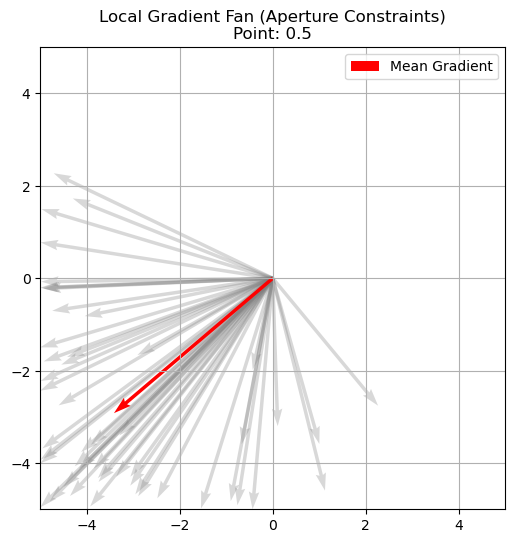

In [44]:


# Plotting the gradients (The 'Constraints')
grads = interrogate_neighborhood(x_star, epsilon=0.3, omega=omega)
plt.figure(figsize=(6, 6))
for g in grads:
    plt.quiver(0, 0, g[0], g[1], color='gray', alpha=0.3, angles='xy', scale_units='xy', scale=1)

# The 'Average' Gradient (Roughly what SHAP might look like)
avg_grad = np.mean(grads, axis=0)
plt.quiver(0, 0, avg_grad[0], avg_grad[1], color='red', label='Mean Gradient', angles='xy', scale_units='xy', scale=1)

plt.xlim(-omega, omega)
plt.ylim(-omega, omega)
plt.title(f"Local Gradient Fan (Aperture Constraints)\nPoint: {x_star[0]}")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
grads

array([[-4.16647902, -4.12296601],
       [-4.99994217, -0.20398358],
       [-4.99118061,  0.7760988 ],
       [-0.66690146, -3.59432011],
       [-4.35891442, -4.71148174],
       [-4.29908808,  1.72768282],
       [-3.84929124, -4.11932688],
       [-4.96221564, -0.20765846],
       [-4.92468576, -1.80021036],
       [-3.06383647, -4.48866868],
       [-4.04377323, -0.81905869],
       [-4.11966847, -3.76095156],
       [-4.9903902 , -3.9257294 ],
       [-0.9025272 , -4.82284172],
       [-4.97172145,  1.49787409],
       [-2.90959363, -1.66174808],
       [-2.89250957, -4.71781013],
       [-4.98953361, -2.22326424],
       [-4.60448109, -2.7510011 ],
       [-4.92814729, -0.22384837],
       [-4.54751522, -1.86939133],
       [-4.9994001 , -1.49591512],
       [-4.70939674,  2.27339328],
       [-0.7600494 , -4.91246221],
       [-4.95375602, -3.6823707 ],
       [-3.06127108, -4.29444168],
       [-4.97940204, -0.07457908],
       [-3.92522593, -4.93906466],
       [-0.43088124,

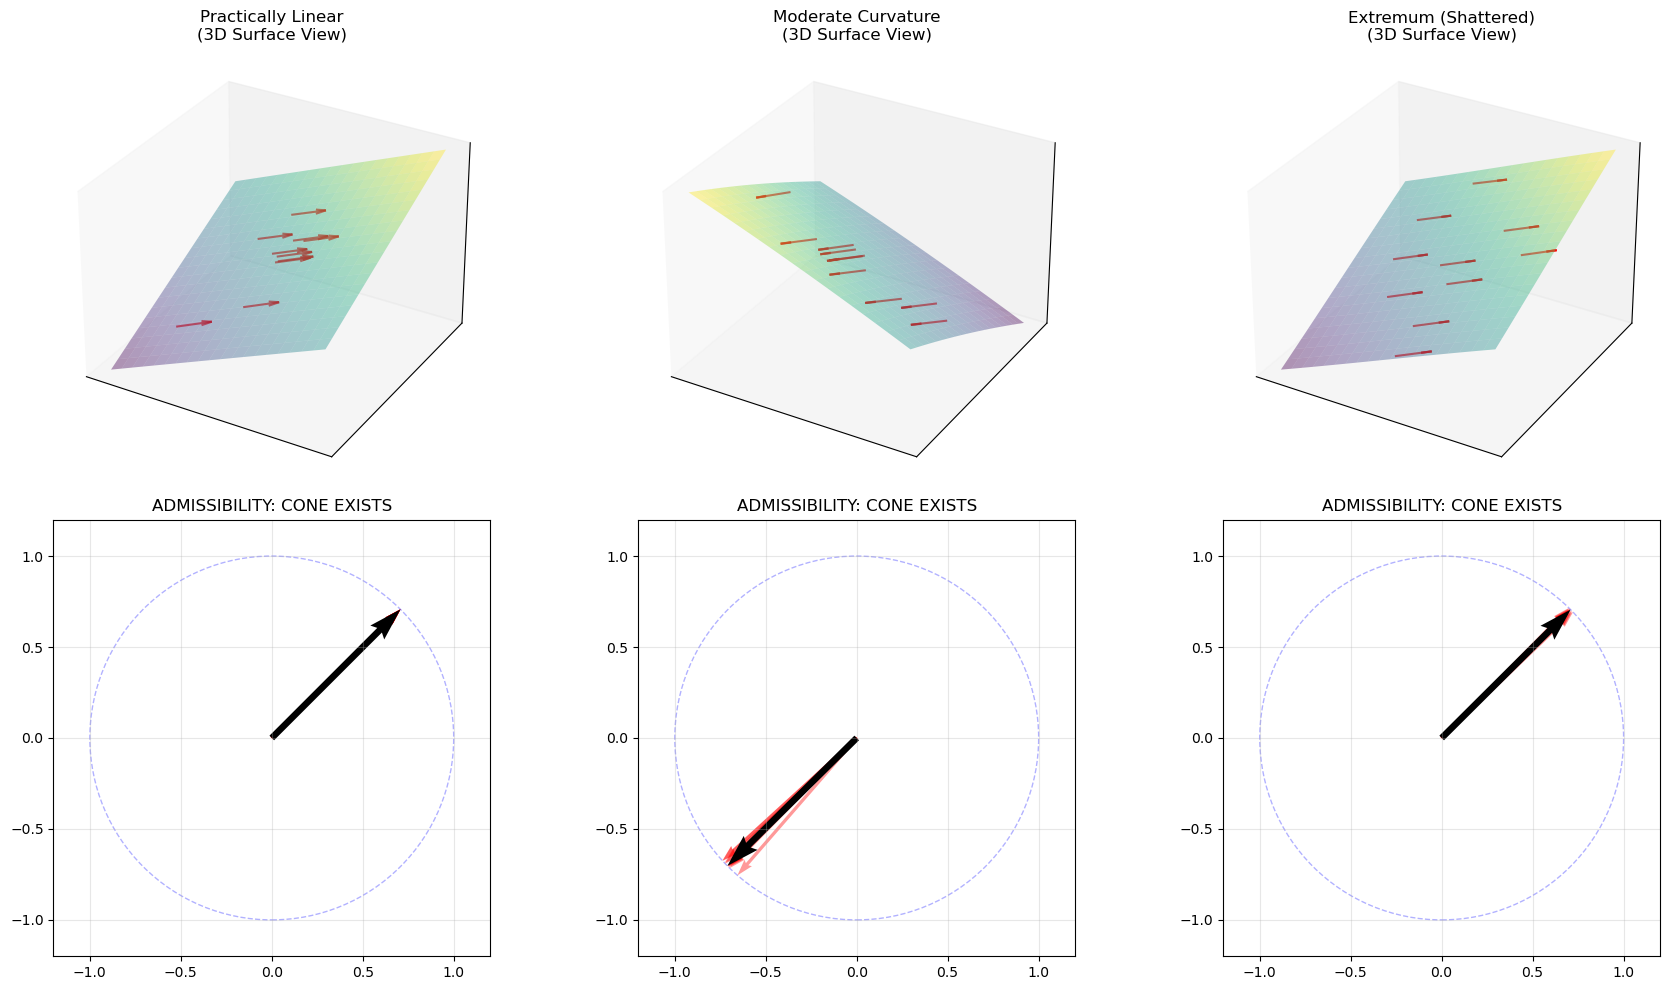

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. FUNCTIONS ---
def manifold_f(x1, x2, omega):
    return np.sin(omega * x1) + np.sin(omega * x2)

def get_grads(points, omega):
    g1 = omega * np.cos(omega * sample_points[:, 0])
    g2 = omega * np.cos(omega * sample_points[:, 1])
    return np.stack([g1, g2], axis=1)

# --- 2. SCENARIOS ---
# 1: Linear (Low omega), 2: Curved (omega=5), 3: Extremum (At peak with high omega)
scenarios = [
    {'name': 'Practically Linear', 'omega': 0.5, 'x_star': [0.5, 0.5]},
    {'name': 'Moderate Curvature', 'omega': 5.0, 'x_star': [0.5, 0.5]},
    {'name': 'Extremum (Shattered)', 'omega': 10.0, 'x_star': [0.0, 0.0]}
]

epsilon = 0.03
n_points = 10
fig = plt.figure(figsize=(18, 10))

for i, s in enumerate(scenarios):
    omega = s['omega']
    x_star = np.array(s['x_star'])
    
    # Generate Neighborhood Data
    res = 20
    x1_range = np.linspace(x_star[0]-epsilon, x_star[0]+epsilon, res)
    x2_range = np.linspace(x_star[1]-epsilon, x_star[1]+epsilon, res)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z = manifold_f(X1, X2, omega)
    
    # Sample points for gradients
    angles = np.random.uniform(0, 2*np.pi, n_points)
    radii = np.random.uniform(0, epsilon, n_points)
    sample_points = x_star + np.stack([radii*np.cos(angles), radii*np.sin(angles)], axis=1)
    grads = get_grads(sample_points, omega)
    
    # --- ROW 1: 3D MANIFOLD ---
    ax3d = fig.add_subplot(2, 3, i+1, projection='3d')
    ax3d.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.4)
    
    # Plot local gradients on surface
    for j in range(n_points):
        p = sample_points[j]
        g = grads[j]
        z_p = manifold_f(p[0], p[1], omega)
        g_norm = g / np.linalg.norm(g) * 0.3*epsilon # scale for 3D
        ax3d.quiver(p[0], p[1], z_p, g_norm[0], g_norm[1], 0, color='red', alpha=0.7)
        
    ax3d.set_title(f"{s['name']}\n(3D Surface View)")
    ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])

    # --- ROW 2: 2D VECTOR CONE ---
    ax2d = fig.add_subplot(2, 3, i+4)
    
    # Normalize all gradients to unit circle to see the "Fan"
    unit_grads = grads / np.linalg.norm(grads, axis=1, keepdims=True)
    
    for g in unit_grads:
        ax2d.quiver(0, 0, g[0], g[1], color='red', angles='xy', scale_units='xy', scale=1, alpha=0.4)
    
    # Calculate "Axiomatic Centroid" (simple mean for POC)
    centroid = np.mean(unit_grads, axis=0)
    centroid /= np.linalg.norm(centroid)
    
    # Plot Centroid
    ax2d.quiver(0, 0, centroid[0], centroid[1], color='black', angles='xy', 
                scale_units='xy', scale=1, width=0.015, label='Centroid')
    
    # Aesthetics
    circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', alpha=0.3)
    ax2d.add_artist(circle)
    ax2d.set_xlim(-1.2, 1.2); ax2d.set_ylim(-1.2, 1.2)
    ax2d.set_aspect('equal')
    ax2d.grid(True, alpha=0.3)
    
    # Detect Shattering
    dot_products = np.dot(unit_grads, unit_grads.T)
    min_dot = np.min(dot_products)
    if min_dot < -0.8: # Roughly > 140 degrees spread
        ax2d.set_facecolor('#ffe6e6')
        ax2d.set_title("ADMISSIBILITY: EMPTY/SHATTERED")
    else:
        ax2d.set_title(f"ADMISSIBILITY: CONE EXISTS")

plt.tight_layout()
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

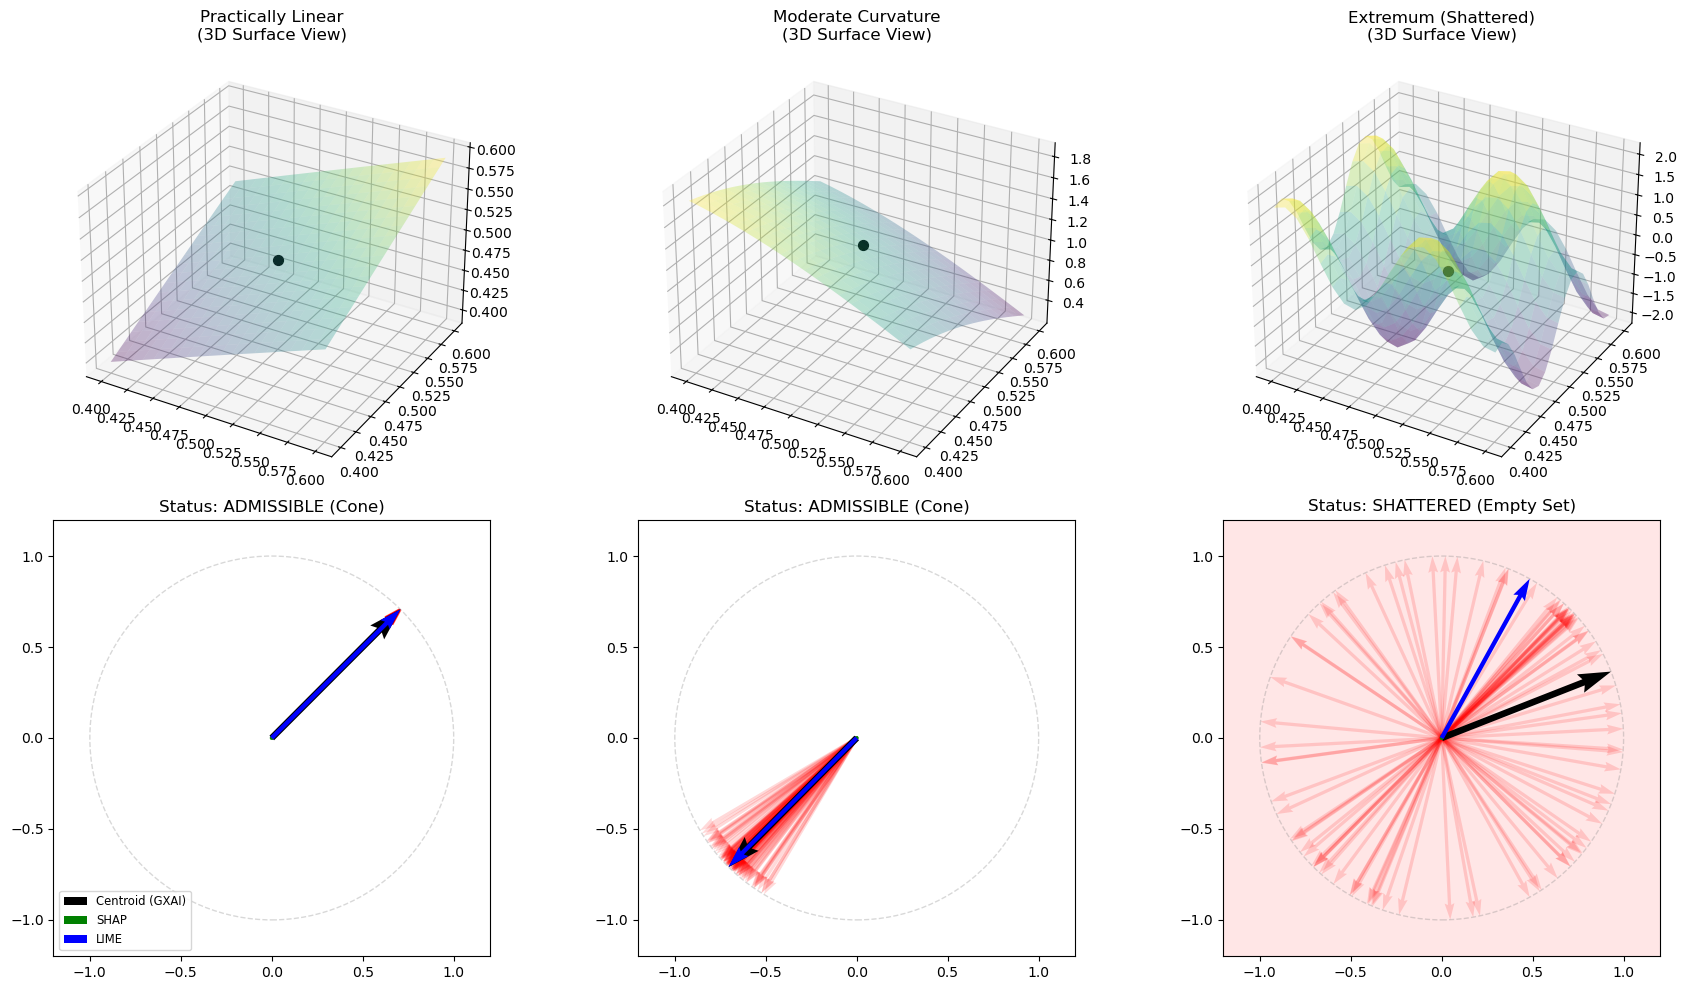

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import shap
import warnings

# Suppress SHAP warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. FUNCTIONS ---
def manifold_f(x1, x2, omega):
    return np.sin(omega * x1) + np.sin(omega * x2)

def model_f_wrapper(X, omega):
    # Ensure input is 2D
    if X.ndim == 1:
        X = X.reshape(1, -1)
    return np.sin(omega * X[:, 0]) + np.sin(omega * X[:, 1])

def get_grads(points, omega):
    g1 = omega * np.cos(omega * points[:, 0])
    g2 = omega * np.cos(omega * points[:, 1])
    return np.stack([g1, g2], axis=1)

# --- 2. SCENARIOS ---
scenarios = [
    {'name': 'Practically Linear', 'omega': 0.5, 'x_star': [0.5, 0.5]},
    {'name': 'Moderate Curvature', 'omega': 5.0, 'x_star': [0.5, 0.5]},
    {'name': 'Extremum (Shattered)', 'omega': 50.0, 'x_star': [0.5, 0.5]}
]

epsilon = 0.1
n_points = 100
fig = plt.figure(figsize=(18, 10))

for i, s in enumerate(scenarios):
    omega = s['omega']
    x_star = np.array(s['x_star'])
    
    # Generate Neighborhood Data
    res = 20
    x1_range = np.linspace(x_star[0]-epsilon, x_star[0]+epsilon, res)
    x2_range = np.linspace(x_star[1]-epsilon, x_star[1]+epsilon, res)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z = manifold_f(X1, X2, omega)
    
    # Sample points for gradients
    angles = np.random.uniform(0, 2*np.pi, n_points)
    radii = np.random.uniform(0, epsilon, n_points)
    sample_points = x_star + np.stack([radii*np.cos(angles), radii*np.sin(angles)], axis=1)
    grads = get_grads(sample_points, omega)
    unit_grads = grads / (np.linalg.norm(grads, axis=1, keepdims=True) + 1e-9)
    
    # --- ROW 1: 3D MANIFOLD ---
    ax3d = fig.add_subplot(2, 3, i+1, projection='3d')
    ax3d.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.3)
    z_star = manifold_f(x_star[0], x_star[1], omega)
    ax3d.scatter(x_star[0], x_star[1], z_star, color='black', s=50)
    ax3d.set_title(f"{s['name']}\n(3D Surface View)")

    # --- ROW 2: 2D VECTOR CONE ---
    ax2d = fig.add_subplot(2, 3, i+4)
    
    for g in unit_grads:
        ax2d.quiver(0, 0, g[0], g[1], color='red', angles='xy', scale_units='xy', scale=1, alpha=0.15)
    
    # 1. Centroid
    centroid = np.mean(unit_grads, axis=0)
    centroid /= (np.linalg.norm(centroid) + 1e-9)
    
    # 2. SHAP (Robust implementation)
    background = x_star.reshape(1, -1)
    # We pass omega via lambda to keep the wrapper clean
    explainer = shap.KernelExplainer(lambda x: model_f_wrapper(x, omega), background, silent=True)
    shap_output = explainer.shap_values(x_star.reshape(1, -1), nsamples=100)
    
    # Handle SHAP output variations (sometimes list of arrays, sometimes array)
    if isinstance(shap_output, list):
        shap_vec = np.array(shap_output[0]).flatten()
    else:
        shap_vec = np.array(shap_output).flatten()
    
    shap_vec /= (np.linalg.norm(shap_vec) + 1e-9)
    
    # 3. LIME
    y_samples = model_f_wrapper(sample_points, omega)
    lime_model = LinearRegression().fit(sample_points, y_samples)
    lime_vec = lime_model.coef_.flatten()
    lime_vec /= (np.linalg.norm(lime_vec) + 1e-9)
    
    # Plotting
    ax2d.quiver(0, 0, centroid[0], centroid[1], color='black', angles='xy', scale_units='xy', scale=1, width=0.015, label='Centroid (GXAI)')
    ax2d.quiver(0, 0, shap_vec[0], shap_vec[1], color='green', angles='xy', scale_units='xy', scale=1, width=0.01, label='SHAP')
    ax2d.quiver(0, 0, lime_vec[0], lime_vec[1], color='blue', angles='xy', scale_units='xy', scale=1, width=0.01, label='LIME')
    
    # Admissibility Check
    min_dot = np.min(np.dot(unit_grads, unit_grads.T))
    status = "SHATTERED (Empty Set)" if min_dot < -0.5 else "ADMISSIBLE (Cone)"
    if min_dot < -0.5: ax2d.set_facecolor('#ffe6e6')
        
    ax2d.set_title(f"Status: {status}")
    ax2d.set_xlim(-1.2, 1.2); ax2d.set_ylim(-1.2, 1.2)
    ax2d.add_artist(plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.3))
    ax2d.set_aspect('equal')
    if i == 0: ax2d.legend(loc='lower left', fontsize='small')

plt.tight_layout()
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

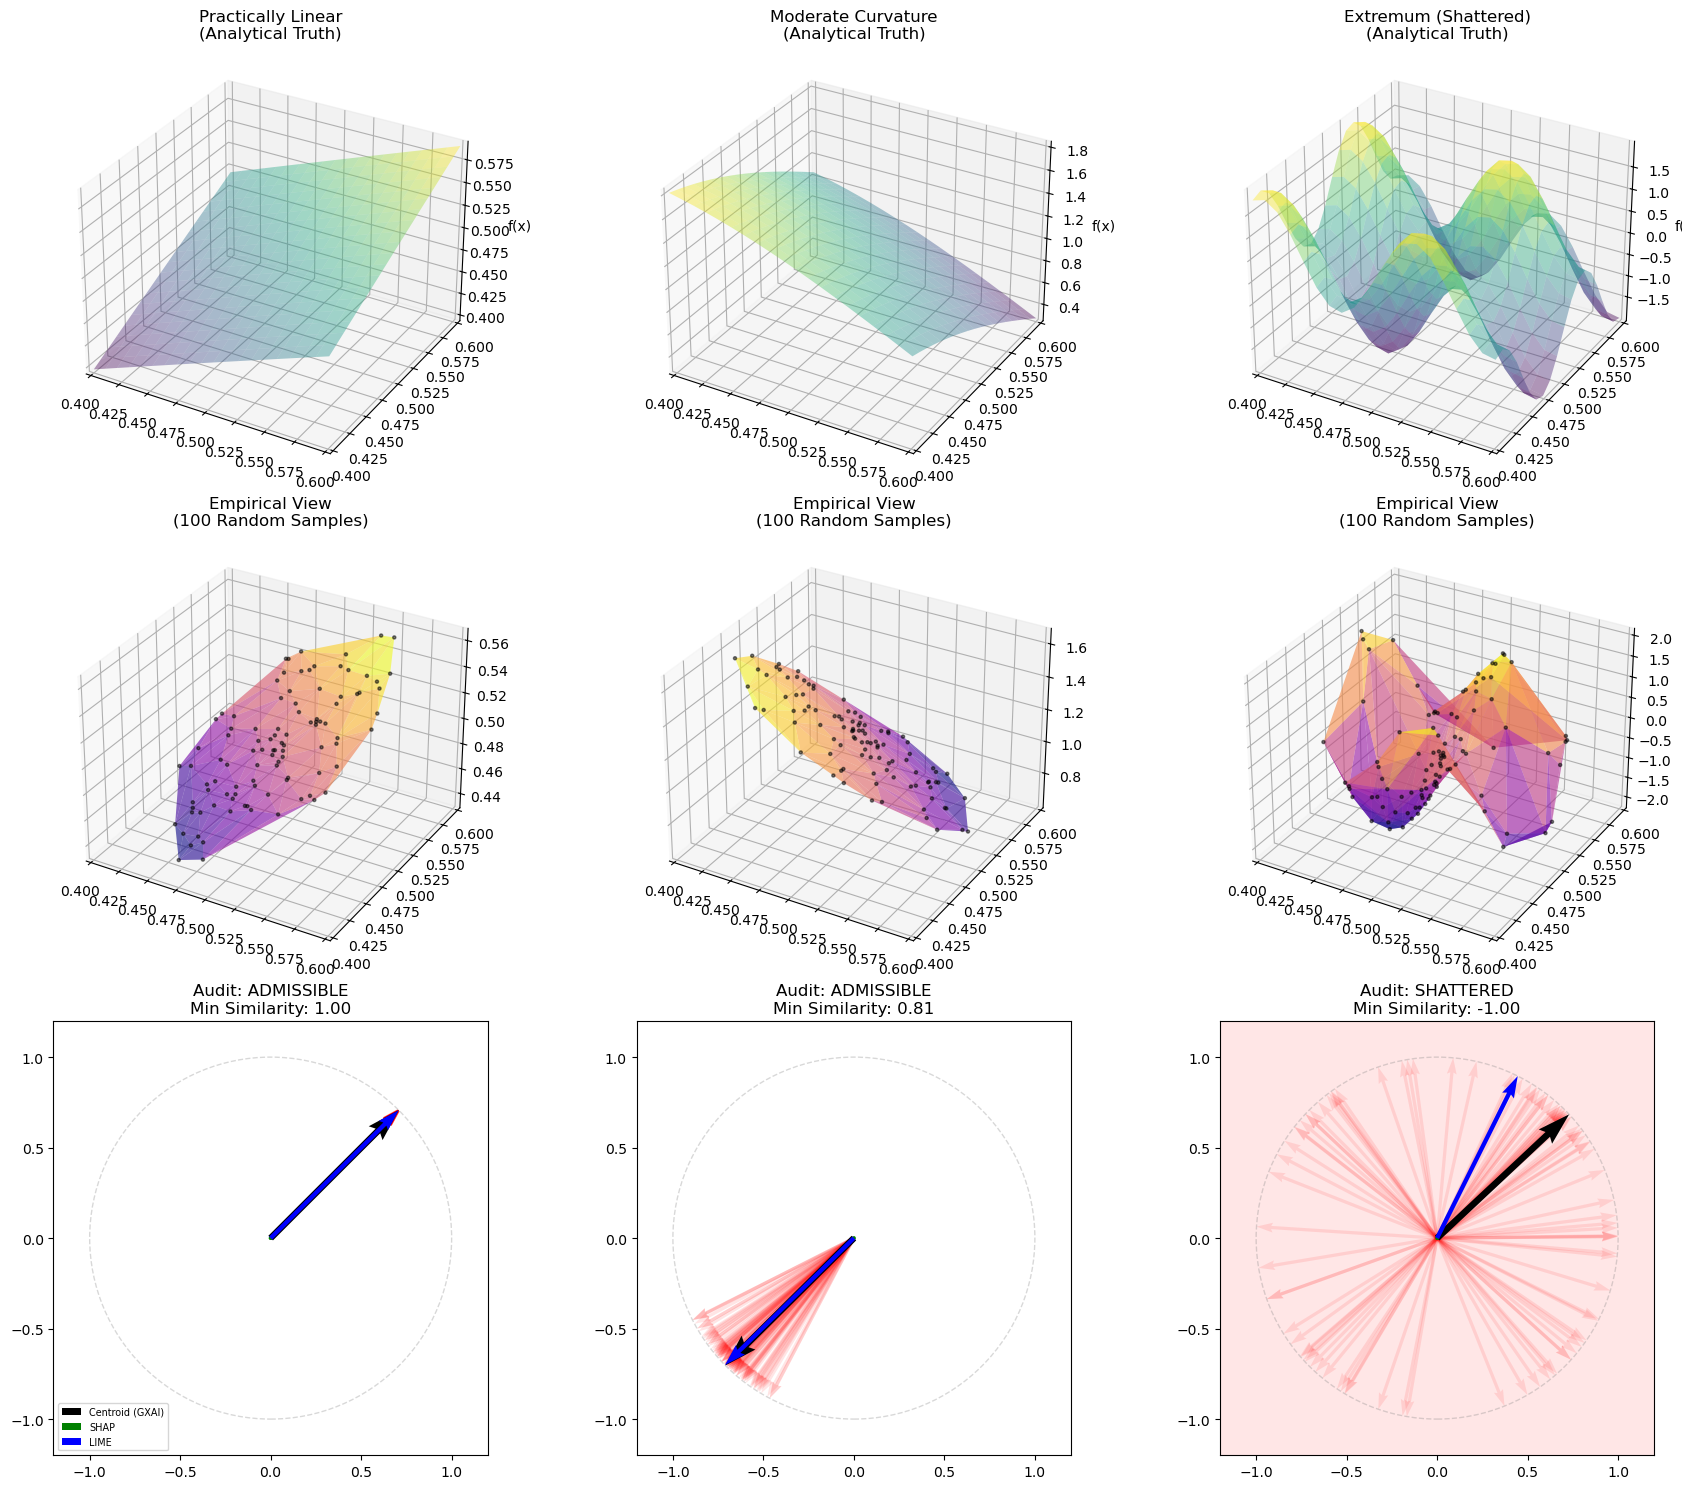

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import shap
import warnings
from matplotlib import cm

# Suppress SHAP warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. FUNCTIONS ---
def manifold_f(x1, x2, omega):
    return np.sin(omega * x1) + np.sin(omega * x2)

def model_f_wrapper(X, omega):
    if X.ndim == 1:
        X = X.reshape(1, -1)
    return np.sin(omega * X[:, 0]) + np.sin(omega * X[:, 1])

def get_grads(points, omega):
    g1 = omega * np.cos(omega * points[:, 0])
    g2 = omega * np.cos(omega * points[:, 1])
    return np.stack([g1, g2], axis=1)

# --- 2. SCENARIOS ---
scenarios = [
    {'name': 'Practically Linear', 'omega': 0.5, 'x_star': [0.5, 0.5]},
    {'name': 'Moderate Curvature', 'omega': 5.0, 'x_star': [0.5, 0.5]},
    {'name': 'Extremum (Shattered)', 'omega': 50.0, 'x_star': [0.5, 0.5]}
]

epsilon = 0.1
n_points = 100
# Increased figure height to accommodate 3 rows
fig = plt.figure(figsize=(18, 15))

for i, s in enumerate(scenarios):
    omega = s['omega']
    x_star = np.array(s['x_star'])
    
    # --- DATA GENERATION ---
    res = 20
    x1_range = np.linspace(x_star[0]-epsilon, x_star[0]+epsilon, res)
    x2_range = np.linspace(x_star[1]-epsilon, x_star[1]+epsilon, res)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z_true = manifold_f(X1, X2, omega)
    
    # Sampling for Gradients and Empirical View
    angles = np.random.uniform(0, 2*np.pi, n_points)
    radii = np.random.uniform(0, epsilon, n_points)
    sample_points = x_star + np.stack([radii*np.cos(angles), radii*np.sin(angles)], axis=1)
    y_samples = model_f_wrapper(sample_points, omega)
    grads = get_grads(sample_points, omega)
    unit_grads = grads / (np.linalg.norm(grads, axis=1, keepdims=True) + 1e-9)

    # --- ROW 1: ANALYTICAL MANIFOLD (Truth) ---
    ax_top = fig.add_subplot(3, 3, i+1, projection='3d')
    ax_top.plot_surface(X1, X2, Z_true, cmap='viridis', alpha=0.4, antialiased=True)
    ax_top.set_title(f"{s['name']}\n(Analytical Truth)")
    ax_top.set_zlabel('f(x)')

    # --- ROW 2: EMPIRICAL MANIFOLD (Finite Samples) ---
    # This shows what the explainer actually constructs from data
    ax_mid = fig.add_subplot(3, 3, i+4, projection='3d')
    # Use trisurf to interpolate the 100 random samples
    ax_mid.plot_trisurf(sample_points[:,0], sample_points[:,1], y_samples, 
                        cmap='plasma', alpha=0.6, linewidth=0.1, antialiased=True)
    ax_mid.scatter(sample_points[:,0], sample_points[:,1], y_samples, color='black', s=5, alpha=0.5)
    ax_mid.set_title(f"Empirical View\n({n_points} Random Samples)")
    
    # Standardize axes for comparison
    for ax in [ax_top, ax_mid]:
        ax.set_xlim(x_star[0]-epsilon, x_star[0]+epsilon)
        ax.set_ylim(x_star[1]-epsilon, x_star[1]+epsilon)

    # --- ROW 3: VECTOR CONE & AUDIT ---
    ax_bot = fig.add_subplot(3, 3, i+7)
    
    # Plotting individual point-wise gradients (The "Voters")
    for g in unit_grads:
        ax_bot.quiver(0, 0, g[0], g[1], color='red', angles='xy', scale_units='xy', scale=1, alpha=0.1)
    
    # 1. Centroid calculation
    centroid = np.mean(unit_grads, axis=0)
    centroid /= (np.linalg.norm(centroid) + 1e-9)
    
    # 2. SHAP
    background = x_star.reshape(1, -1)
    explainer = shap.KernelExplainer(lambda x: model_f_wrapper(x, omega), background, silent=True)
    shap_output = explainer.shap_values(x_star.reshape(1, -1), nsamples=100)
    shap_vec = np.array(shap_output[0]).flatten() if isinstance(shap_output, list) else np.array(shap_output).flatten()
    shap_vec /= (np.linalg.norm(shap_vec) + 1e-9)
    
    # 3. LIME
    lime_model = LinearRegression().fit(sample_points, y_samples)
    lime_vec = lime_model.coef_.flatten()
    lime_vec /= (np.linalg.norm(lime_vec) + 1e-9)
    
    # Plot Explainer Vectors
    ax_bot.quiver(0, 0, centroid[0], centroid[1], color='black', angles='xy', scale_units='xy', scale=1, width=0.015, label='Centroid (GXAI)')
    ax_bot.quiver(0, 0, shap_vec[0], shap_vec[1], color='green', angles='xy', scale_units='xy', scale=1, width=0.01, label='SHAP')
    ax_bot.quiver(0, 0, lime_vec[0], lime_vec[1], color='blue', angles='xy', scale_units='xy', scale=1, width=0.01, label='LIME')
    
    # Audit Logic
    min_dot = np.min(np.dot(unit_grads, unit_grads.T))
    status = "SHATTERED" if min_dot < -0.1 else "ADMISSIBLE"
    if min_dot < -0.1: ax_bot.set_facecolor('#ffe6e6')
        
    ax_bot.set_title(f"Audit: {status}\nMin Similarity: {min_dot:.2f}")
    ax_bot.set_xlim(-1.2, 1.2); ax_bot.set_ylim(-1.2, 1.2)
    ax_bot.add_artist(plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.3))
    ax_bot.set_aspect('equal')
    if i == 0: ax_bot.legend(loc='lower left', fontsize='x-small')

plt.tight_layout()
plt.show()

Plot saved as epsilon_theta_relationship.png


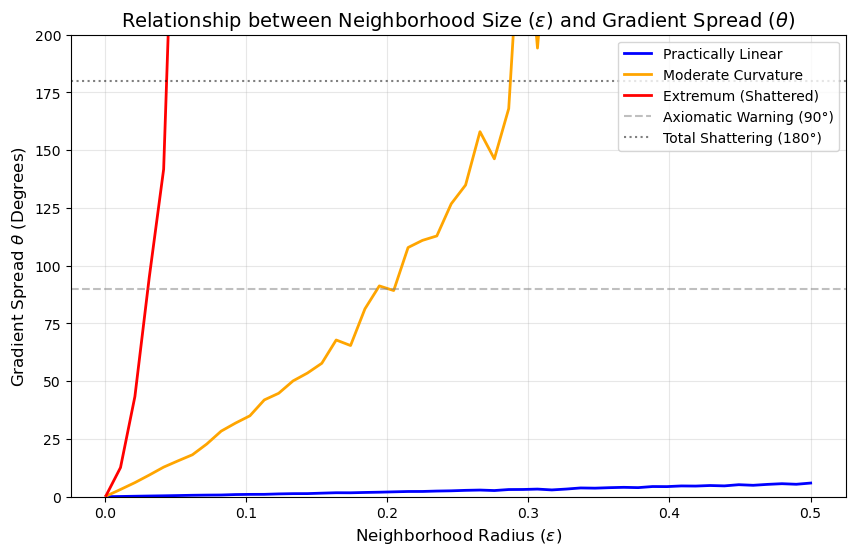

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def get_grads(points, omega):
    g1 = omega * np.cos(omega * points[:, 0])
    g2 = omega * np.cos(omega * points[:, 1])
    return np.stack([g1, g2], axis=1)

def calculate_theta(omega, x_star, epsilon, n_points=200):
    # Sample points in a disk of radius epsilon
    angles = np.random.uniform(0, 2*np.pi, n_points)
    radii = np.random.uniform(0, epsilon, n_points)
    sample_points = x_star + np.stack([radii*np.cos(angles), radii*np.sin(angles)], axis=1)
    
    # Get gradients
    grads = get_grads(sample_points, omega)
    # Normalize
    norms = np.linalg.norm(grads, axis=1, keepdims=True) + 1e-9
    unit_grads = grads / norms
    
    # Compute all-pairs dot products to find the minimum (max angular distance)
    # Since n_points is small (200), we can do this.
    # Alternatively, find min/max angle using arctan2
    vec_angles = np.arctan2(unit_grads[:, 1], unit_grads[:, 0])
    
    # Handle wrapping: the spread is the smallest arc containing all angles
    vec_angles = np.sort(vec_angles)
    diffs = np.diff(vec_angles)
    max_gap = 2*np.pi - (vec_angles[-1] - vec_angles[0])
    theta = 2*np.pi - max(max(diffs), max_gap)
    
    return np.degrees(theta)

scenarios = [
    {'name': 'Practically Linear', 'omega': 0.5, 'color': 'blue'},
    {'name': 'Moderate Curvature', 'omega': 5.0, 'color': 'orange'},
    {'name': 'Extremum (Shattered)', 'omega': 50.0, 'color': 'red'}
]

x_star = np.array([0.5, 0.5])
epsilons = np.linspace(0.001, 0.5, 50)

plt.figure(figsize=(10, 6))

for s in scenarios:
    thetas = [calculate_theta(s['omega'], x_star, e) for e in epsilons]
    plt.plot(epsilons, thetas, label=s['name'], color=s['color'], lw=2)

plt.axhline(y=90, color='gray', linestyle='--', alpha=0.5, label='Axiomatic Warning (90°)')
plt.axhline(y=180, color='black', linestyle=':', alpha=0.5, label='Total Shattering (180°)')

plt.title('Relationship between Neighborhood Size ($\epsilon$) and Gradient Spread ($\\theta$)', fontsize=14)
plt.xlabel('Neighborhood Radius ($\epsilon$)', fontsize=12)
plt.ylabel('Gradient Spread $\\theta$ (Degrees)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 200)

plt.savefig('epsilon_theta_relationship.png')
print("Plot saved as epsilon_theta_relationship.png")

 
 ##### Processing Scenario: Practically Linear with omega=0.5 ##### 


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Practically Linear - Feasible Set Size: 136 / 1000


  0%|          | 0/1 [00:00<?, ?it/s]

Practically Linear - SHAP Vector: [-0.06853694 -0.99764816]
 
 ##### Processing Scenario: Moderate Curvature with omega=5.0 ##### 
Moderate Curvature - Feasible Set Size: 0 / 1000


  0%|          | 0/1 [00:00<?, ?it/s]

Moderate Curvature - SHAP Vector: [0.65650954 0.75431767]
 
 ##### Processing Scenario: Extremum (Shattered) with omega=50.0 ##### 
Extremum (Shattered) - Feasible Set Size: 0 / 1000


  0%|          | 0/1 [00:00<?, ?it/s]

Extremum (Shattered) - SHAP Vector: [-0.88760016 -0.46061475]


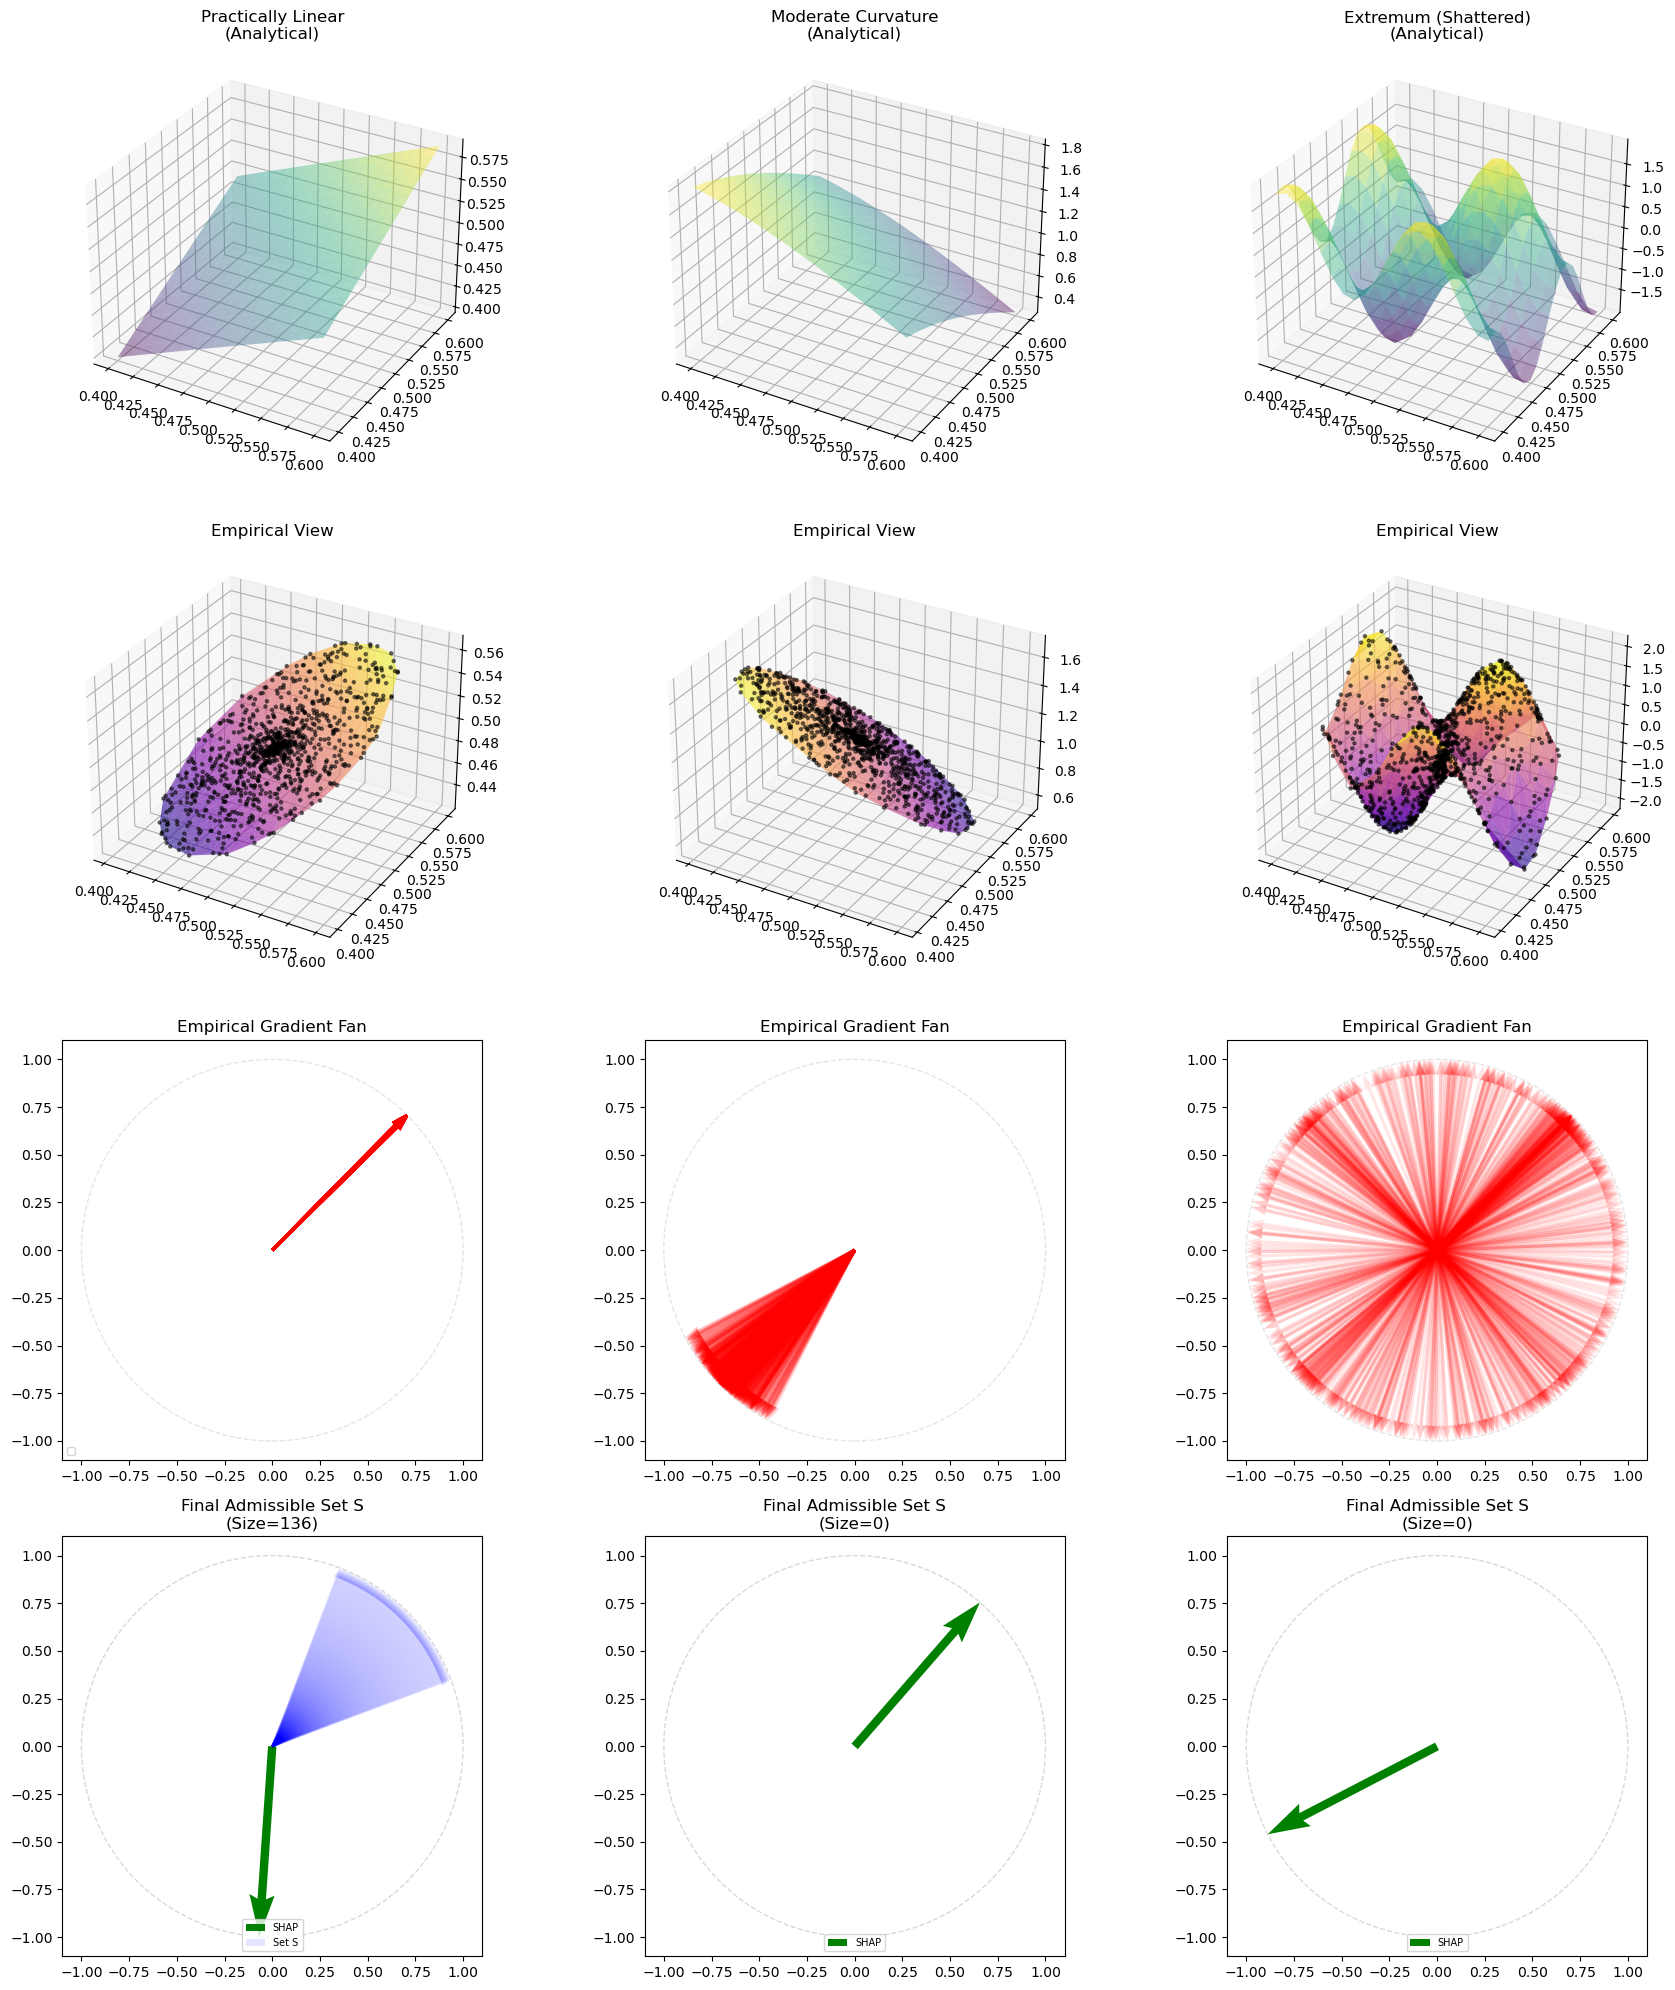

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import shap
import warnings

warnings.filterwarnings('ignore')

# --- 1. ROBUST FILTER ---
tau = {
    'sign': 0.1,    # Threshold for A1
    'null': 0.2,    # Threshold for A2
    'rank': 0.05,   # Threshold for A3
    'deg':  25.0    # Threshold for A4
}

def is_axiomatically_valid(e, neighborhood_grads, tau):
    e_unit = e / (np.linalg.norm(e) + 1e-9)
    
    for g in neighborhood_grads:
        g_unit = g / (np.linalg.norm(g) + 1e-9)
        
        # A1: Sign Consistency (with tau_sign floor)
        for j in range(len(e_unit)):
            if np.abs(g_unit[j]) > tau['sign']: 
                if np.sign(e_unit[j]) != np.sign(g_unit[j]): return False
        
        # A2: Nullity (with tau_null ceiling)
        for j in range(len(g_unit)):
            if np.abs(g_unit[j]) < tau['sign']: # Using sign floor as the nullity definition
                if np.abs(e_unit[j]) > tau['null']: return False
        
        # A3: Ranking (with tau_rank buffer)
        g_diff = np.abs(g_unit[0]) - np.abs(g_unit[1])
        e_diff = np.abs(e_unit[0]) - np.abs(e_unit[1])
        if np.abs(g_diff) > tau['rank']:
            if np.sign(g_diff) != np.sign(e_diff): return False
            
        # A4: Proportionality (with tau_deg angular limit)
        dot = np.clip(np.dot(e_unit, g_unit), -1.0, 1.0)
        if np.degrees(np.arccos(dot)) > tau['deg']: return False
        
    return True

# --- 2. SETUP & SCENARIOS ---
def manifold_f(x1, x2, omega): return np.sin(omega * x1) + np.sin(omega * x2)
def model_f_wrapper(X, omega): 
    return np.sin(omega * X[:, 0]) + np.sin(omega * X[:, 1]) if X.ndim > 1 else np.sin(omega * X[0]) + np.sin(omega * X[1])
def get_grads(points, omega):
    return np.stack([omega * np.cos(omega * points[:, 0]), omega * np.cos(omega * points[:, 1])], axis=1)

scenarios = [
    {'name': 'Practically Linear', 'omega': 0.5, 'x_star': [0.5, 0.5]},
    {'name': 'Moderate Curvature', 'omega': 5.0, 'x_star': [0.5, 0.5]},
    {'name': 'Extremum (Shattered)', 'omega': 50.0, 'x_star': [0.5, 0.5]}
]

epsilon = 0.1
n_points = 1000

# Prepare candidate vectors for Row 4
n_test = 1000
test_angles = np.linspace(0, 2*np.pi, n_test)
candidates = np.stack([np.cos(test_angles), np.sin(test_angles)], axis=1)

fig = plt.figure(figsize=(18, 20))

for i, s in enumerate(scenarios):
    print(f" \n ##### Processing Scenario: {s['name']} with omega={s['omega']} ##### ") 

    omega, x_star = s['omega'], np.array(s['x_star'])
    
    # Data Generation
    res = 20
    x1_range = np.linspace(x_star[0]-epsilon, x_star[0]+epsilon, res)
    x2_range = np.linspace(x_star[1]-epsilon, x_star[1]+epsilon, res)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z_true = manifold_f(X1, X2, omega)
    
    angles = np.random.uniform(0, 2*np.pi, n_points)
    radii = np.random.uniform(0, epsilon, n_points)
    sample_points = x_star + np.stack([radii*np.cos(angles), radii*np.sin(angles)], axis=1)
    y_samples = model_f_wrapper(sample_points, omega)
    grads = get_grads(sample_points, omega)
    unit_grads = grads / (np.linalg.norm(grads, axis=1, keepdims=True) + 1e-9)

    # --- ROW 1: ANALYTICAL ---
    ax1 = fig.add_subplot(4, 3, i+1, projection='3d')
    ax1.plot_surface(X1, X2, Z_true, cmap='viridis', alpha=0.4)
    ax1.set_title(f"{s['name']}\n(Analytical)")

    # --- ROW 2: EMPIRICAL ---
    ax2 = fig.add_subplot(4, 3, i+4, projection='3d')
    ax2.plot_trisurf(sample_points[:,0], sample_points[:,1], y_samples, cmap='plasma', alpha=0.6)
    ax2.scatter(sample_points[:,0], sample_points[:,1], y_samples, color='black', s=5, alpha=0.5)
    ax2.set_title("Empirical View")

    

    # --- ROW 3: STANDARD EXPLAINERS (FIXED) ---
    ax3 = fig.add_subplot(4, 3, i+7)

    # 1. Plot the Gradient Fan (The "Voters")
    # CRITICAL: Added angles='xy' to match the coordinate system
    for g in unit_grads: 
        ax3.quiver(0, 0, g[0], g[1], 
                color='red', alpha=0.1, 
                angles='xy', scale_units='xy', scale=1)

    # 2. Aesthetics and Bounds
    ax3.set_title("Empirical Gradient Fan")
    ax3.set_xlim(-1.1, 1.1)
    ax3.set_ylim(-1.1, 1.1)
    ax3.set_aspect('equal')
    ax3.add_artist(plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.2))

    if i == 0: 
        ax3.legend(loc='lower left', fontsize='x-small')

    # --- ROW 4: FINAL AXIOMATIC CONE (The Sieve) ---
    ax4 = fig.add_subplot(4, 3, i+10)

    # 1. Filter candidates through the robust axiomatic check
    valid_set = [c for c in candidates if is_axiomatically_valid(c, unit_grads, tau)]
    print(f"{s['name']} - Feasible Set Size: {len(valid_set)} / {n_test}")


    # 2. Calculate SHAP for this scenario
    # Use the average of your neighborhood or the whole sample set
    background = shap.utils.sample(sample_points, 100) 
    explainer = shap.KernelExplainer(lambda x: model_f_wrapper(x, omega), background, silent=True)
    shap_vals = explainer.shap_values(x_star.reshape(1, -1), nsamples=100)
    shap_vec = np.array(shap_vals).flatten()
    shap_vec /= (np.linalg.norm(shap_vec) + 1e-9)
    print(f"{s['name']} - SHAP Vector: {shap_vec}")

    # 3. Plot SHAP (Increased width for visibility)
    ax4.quiver(0, 0, shap_vec[0], shap_vec[1], 
            color='green', angles='xy', scale_units='xy', scale=1, 
            width=0.02, label='SHAP')
    
    # 4. Plot Valid Set (The "Admissible Cone")    
    if len(valid_set) > 0:
        valid_set = np.array(valid_set)
        # We create an array of zeros for the origins
        origins_x = np.zeros(len(valid_set))
        origins_y = np.zeros(len(valid_set))
        
        ax4.quiver(origins_x, origins_y, valid_set[:, 0], valid_set[:, 1], 
                color='blue', alpha=0.1, angles='xy', scale_units='xy', scale=1,
                width=0.005, label='Set S')


    ax4.set_title(f"Final Admissible Set S\n(Size={len(valid_set)})")
    ax4.set_xlim(-1.1, 1.1); ax4.set_ylim(-1.1, 1.1)
    ax4.add_artist(plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.3))
    ax4.set_aspect('equal')
    ax4.legend(loc='lower center', fontsize='7')

plt.tight_layout()
plt.show()

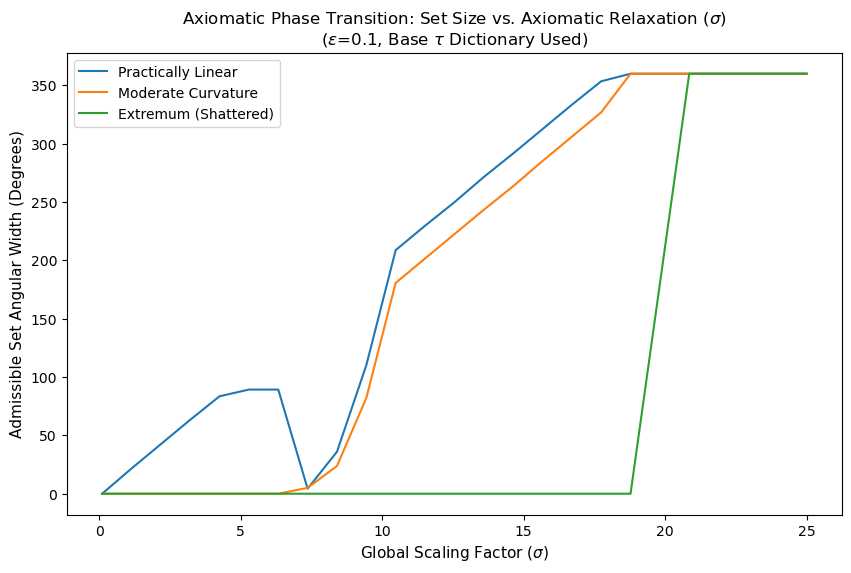

Scenario  Extremum (Shattered)  Moderate Curvature  Practically Linear
Sigma                                                                 
0.1000                     0.0                0.00                0.00
1.1375                     0.0                0.00               21.60
2.1750                     0.0                0.00               42.48
3.2125                     0.0                0.00               63.36
4.2500                     0.0                0.00               83.52
5.2875                     0.0                0.00               89.28
6.3250                     0.0                0.00               89.28
7.3625                     0.0                5.04                4.32
8.4000                     0.0               23.76               36.00
9.4375                     0.0               82.08              110.16
10.4750                    0.0              180.72              208.80
11.5125                    0.0              201.60              229.68
12.550

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

def get_grads(points, omega):
    g1 = omega * np.cos(omega * points[:, 0])
    g2 = omega * np.cos(omega * points[:, 1])
    return np.stack([g1, g2], axis=1)

def is_axiomatically_valid(e_unit, neighborhood_grads, tau_dict):
    # A4: Proportionality (Angular Distance) - Check this first for efficiency
    # But A1-A3 are more restrictive usually
    
    for g in neighborhood_grads:
        g_norm = np.linalg.norm(g)
        if g_norm < 1e-9: continue
        g_unit = g / g_norm
        
        # A1: Sign Consistency
        for j in range(len(e_unit)):
            if np.abs(g_unit[j]) > tau_dict['sign']: 
                if np.sign(e_unit[j]) != np.sign(g_unit[j]): return False
        
        # A2: Nullity
        for j in range(len(g_unit)):
            if np.abs(g_unit[j]) < tau_dict['sign']:
                if np.abs(e_unit[j]) > tau_dict['null']: return False
        
        # A3: Ranking
        g_diff = np.abs(g_unit[0]) - np.abs(g_unit[1])
        e_diff = np.abs(e_unit[0]) - np.abs(e_unit[1])
        if np.abs(g_diff) > tau_dict['rank']:
            if np.sign(g_diff) != np.sign(e_diff): return False
            
        # A4: Proportionality (Angular Distance)
        dot = np.clip(np.dot(e_unit, g_unit), -1.0, 1.0)
        if np.degrees(np.arccos(dot)) > tau_dict['deg']: return False
        
    return True

# Setup
scenarios = [
    {'name': 'Practically Linear', 'omega': 0.5, 'color': 'blue'},
    {'name': 'Moderate Curvature', 'omega': 5.0, 'color': 'orange'},
    {'name': 'Extremum (Shattered)', 'omega': 50.0, 'color': 'red'}
]

x_star = np.array([0.5, 0.5])
epsilon = 0.1
n_points = 100
n_test = 500
test_angles = np.linspace(0, 2*np.pi, n_test)
candidates = np.stack([np.cos(test_angles), np.sin(test_angles)], axis=1)

# --- THE GLOBAL SCALING SWEEP ---
base_tau = {'sign': 0.1, 'null': 0.1, 'rank': 0.05, 'deg': 10.0}
sigmas = np.linspace(0.1, 25.0, 25) # From strict to very relaxed

plt.figure(figsize=(10, 6))

results = {}
for s in scenarios:
    omega = s['omega']
    
    # Generate neighborhood gradients
    angles = np.random.uniform(0, 2*np.pi, n_points)
    radii = np.random.uniform(0, epsilon, n_points)
    sample_points = x_star + np.stack([radii*np.cos(angles), radii*np.sin(angles)], axis=1)
    grads = get_grads(sample_points, omega)
    unit_grads = grads / (np.linalg.norm(grads, axis=1, keepdims=True) + 1e-9)
    
    set_sizes = []
    for sigma in sigmas:
        # Scale all thresholds simultaneously
        current_tau = {k: v * sigma for k, v in base_tau.items()}
        
        valid_count = sum(1 for c in candidates if is_axiomatically_valid(c, unit_grads, current_tau))
        angular_width = (valid_count / n_test) * 360
        set_sizes.append(angular_width)
    
    results[s['name']] = [sigmas, set_sizes]
    

    plt.plot(sigmas, set_sizes, label=s['name'])

# Update axis to reflect the Global Scaling Factor sigma
plt.title(f'Axiomatic Phase Transition: Set Size vs. Axiomatic Relaxation ($\sigma$)\n($\epsilon$={epsilon}, Base $\\tau$ Dictionary Used)', fontsize=12)
plt.xlabel('Global Scaling Factor ($\sigma$)', fontsize=11)
plt.ylabel('Admissible Set Angular Width (Degrees)', fontsize=11)
plt.legend()
plt.show()

# turn results into a table for better visibility
import pandas as pd
table_data = []
for scenario, (sigmas, sizes) in results.items():
    for sigma, size in zip(sigmas, sizes):
        table_data.append({'Scenario': scenario, 'Sigma': sigma, 'Set Size (Degrees)': size})
df = pd.DataFrame(table_data)
print(df.pivot(index='Sigma', columns='Scenario', values='Set Size (Degrees)').round(2))